First QA of the 303(d) regridding: verify that we can reproduce Ecology's DOmin values on the grid.

Ecology provides DOmin values for all of their runs on their webmap on the 303(d) grid. We also have their model output files. So if we are regridding correctly, we should be able to reproduce their DOmin numbers.

Because Ecology rounds their DO values, and because regridding can be complex with different numbers of TCEs mapping to grid rectangles, we test all the cells to look for any discrepancies.

In [1]:
case_file = '/home/benr/wqmodels/ssm/psi/projects/Ecy25_analysis/SSM_config_ecy25.yaml'
run_dir = 'wqm_baseline'

import os
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append('../../py_scripts')
import ssm_utils
import calc_noncompliance

In [2]:
ssm, case = ssm_utils.read_case(case_file)

Inferring case name to be ecy25


In [3]:
gdf_tce = gpd.read_file(ssm['paths']['shapefile']).set_index('tce')
gdf_303d = gpd.read_file(ssm['paths']['303d']['shapefile']
                ).set_index('id_303d').rename(columns={
                    'area_m2': 'Area_m2'
                })
newgrid_mapping = pd.read_csv(ssm['paths']['303d']['regrid'])
newgrid_mapping.set_index(newgrid_mapping.columns[0], inplace=True)
model_var='DOXG'
# I often make processed_output relative to the case file
processed_netcdf_dir = Path(case_file).parent / Path(ssm['paths']['processed_output'])/case/model_var
assert os.path.isdir(processed_netcdf_dir)

In [4]:
run_file = processed_netcdf_dir/run_dir/'wc'/f'daily_min_{model_var}_wc.nc'
with xr.open_dataset(run_file) as ds:
    MinDO_tce = ds[f'{model_var}_daily_min_wc']

In [6]:
regridder = calc_noncompliance.Regridder(gdf_tce, gdf_303d, newgrid_mapping, 'tce', 'id_303d')
MinDO_303d = regridder.regrid(MinDO_tce)

/home/benr/wqmodels/ssm/psi/SalishSeaModel-analysis_2026update/bens_qa/calc_noncompliance/../../py_scripts/calc_noncompliance.py:56: RuntimeWarning: invalid value encountered in scalar divide
  values[i] = row[col_area] * depths.loc[oldcell] / total_vol
/home/benr/wqmodels/ssm/psi/SalishSeaModel-analysis_2026update/bens_qa/calc_noncompliance/../../py_scripts/calc_noncompliance.py:56: RuntimeWarning: invalid value encountered in scalar divide
  values[i] = row[col_area] * depths.loc[oldcell] / total_vol
/home/benr/wqmodels/ssm/psi/SalishSeaModel-analysis_2026update/bens_qa/calc_noncompliance/../../py_scripts/calc_noncompliance.py:56: RuntimeWarning: invalid value encountered in scalar divide
  values[i] = row[col_area] * depths.loc[oldcell] / total_vol
/home/benr/wqmodels/ssm/psi/SalishSeaModel-analysis_2026update/bens_qa/calc_noncompliance/../../py_scripts/calc_noncompliance.py:56: RuntimeWarning: invalid value encountered in scalar divide
  values[i] = row[col_area] * depths.loc[oldce

In [7]:
MinDO_annual_303d = MinDO_303d.min(axis=(0,1))

In [8]:
domin_df = gpd.GeoDataFrame({
    'ecology': gdf_303d['min_exist'],
    'ours': MinDO_annual_303d
}, geometry=gdf_303d.geometry, crs=gdf_303d.crs, index=gdf_303d.index)
domin_df.head()

,ecology,ours,geometry
id_303d,,,
47122A9I7,6.7,6.701850,"POLYGON ((502171.347 5215145.776, 502162.733 5..."
47122A9I8,6.9,6.863636,"POLYGON ((501422.653 5215145.543, 501422.677 5..."
47122A9J6,6.5,6.491972,"POLYGON ((502940.13 5216257.39, 502940.302 521..."
47122A9J7,6.6,6.548422,"POLYGON ((502181.254 5216257.056, 502181.395 5..."
47122B5H9,5.3,5.263892,"POLYGON ((530971.919 5225228.193, 530972.418 5..."


In [9]:
failed_matches = domin_df.loc[domin_df['ours'].round(1) != domin_df['ecology']]
print(f'{len(failed_matches)} failed matches out of {len(domin_df)} grid cells')
failed_matches

528 failed matches out of 8224 grid cells


,ecology,ours,geometry
id_303d,,,
47122A9J7,6.6,6.548422,"POLYGON ((502181.254 5216257.056, 502181.395 5..."
47122B6D6,5.3,5.247254,"POLYGON ((525687.109 5220757.557, 525687.437 5..."
47122B6E7,5.4,5.347033,"POLYGON ((524924.144 5221865.609, 524924.816 5..."
47122B6H1,5.3,5.242692,"POLYGON ((529456.454 5225220.435, 529456.58 52..."
47122B6I3,5.5,5.448376,"POLYGON ((527935.772 5226324.358, 527935.982 5..."
...,...,...,...
48124E7J1,2.4,NaN,"POLYGON ((373301.972 5372160.216, 372816.968 5..."
48124E7J2,2.4,NaN,"POLYGON ((372821.394 5372367.308, 372816.968 5..."
48124E8A0,2.4,NaN,"POLYGON ((366696.907 5363415.089, 366670.769 5..."


At first glance there are two problems: some of the values are NaN (as we could have predicted from the divide by zero warnings earlier) and some are close but just don't round off quite to Ecology's value. Let's plot these cells to look for patterns.

NaNs are depicted in red and the others are orange.

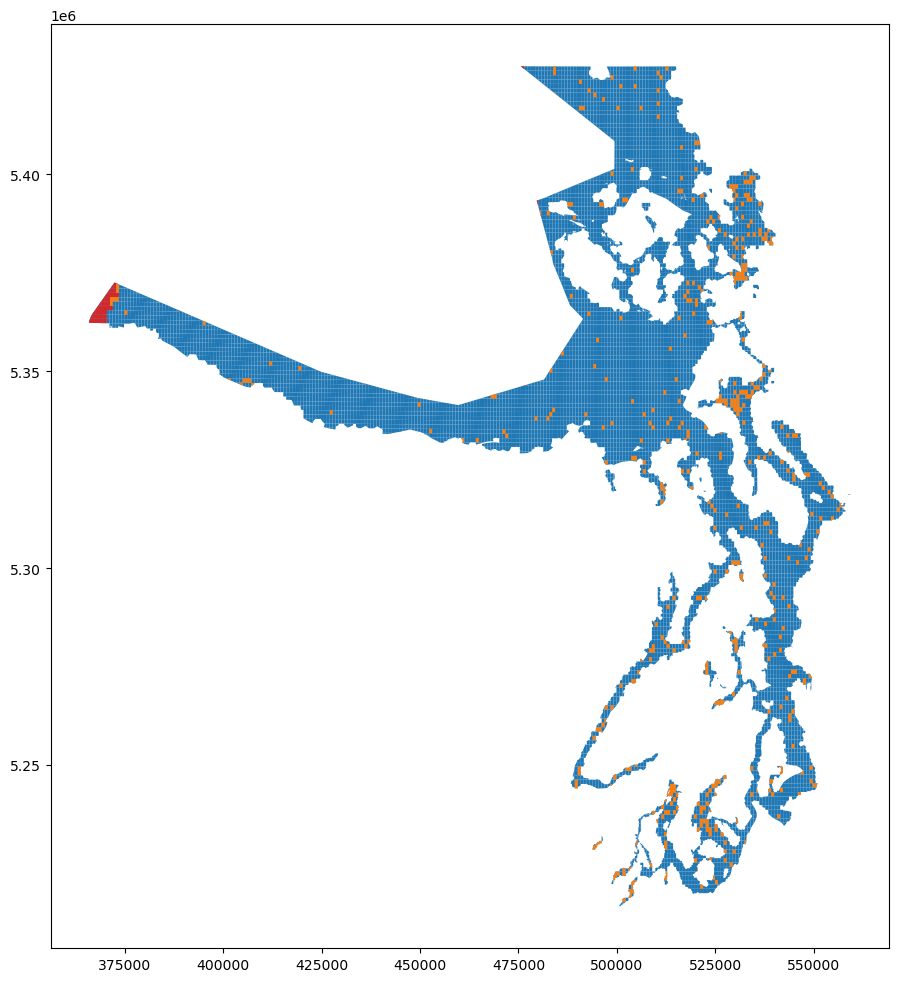

In [10]:
fig, ax = plt.subplots(figsize=(12,12))
gdf_303d.plot(ax=ax)
gdf_303d.loc[
    failed_matches.loc[pd.isna(failed_matches['ours'])].index
].plot(ax=ax, color='tab:red')
gdf_303d.loc[
    failed_matches.loc[~pd.isna(failed_matches['ours'])].index
].plot(ax=ax, color='tab:orange');

The red cells are clearly all in one area. I think what's going on here is that we lack depth information in the shapefile for all the TCEs that contribute to those 303d regions. I also see one orange cell right on the border; that's probably due to having a contribution from a zero-depth TCE. But the others don't appear to be located in places where I would expect to encounter problems with our depth data.

From consulting Appendix D, I suspect the other inaccuracies are due to not accounting for the hourly changes in surface elevation with the tide. Ecology makes it pretty explicit that they computed hourly TCE volumes to do their regridding, whereas I'm just doing a shotgun approach with a single weights matrix for the entire year.

In [11]:
failed_matches.to_file('regrid303d_fails.shp')

Let's see if we can fix these problems. First the easy one: load complete grid depth information into the shapefile and try again.

In [12]:
grid_depths = pd.read_excel('ssm_grid_depths.xlsx', index_col=[0])
grid_depths.head()

,geometry,depth
1,POINT (413209 4916091),102.7573
2,POINT (400581 4916573),128.4466
3,POINT (390430 4916456),128.4466
4,POINT (380630 4918330),131.3113
5,POINT (375680 4925140),164.1391


In [13]:
gdf_tce['depth'] = grid_depths['depth']
gdf_tce['depth'].head()

tce
1    102.7573
2    128.4466
3    128.4466
4    131.3113
5    164.1391
Name: depth, dtype: float64

In [14]:
regridder = calc_noncompliance.Regridder(gdf_tce, gdf_303d, newgrid_mapping, 'tce', 'id_303d')
MinDO_303d = regridder.regrid(MinDO_tce)

In [15]:
MinDO_annual_303d = MinDO_303d.min(axis=(0,1))
domin_df = gpd.GeoDataFrame({
    'ecology': gdf_303d['min_exist'],
    'ours': MinDO_annual_303d
}, geometry=gdf_303d.geometry, crs=gdf_303d.crs, index=gdf_303d.index)
domin_df.head()

,ecology,ours,geometry
id_303d,,,
47122A9I7,6.7,6.701850,"POLYGON ((502171.347 5215145.776, 502162.733 5..."
47122A9I8,6.9,6.863656,"POLYGON ((501422.653 5215145.543, 501422.677 5..."
47122A9J6,6.5,6.491976,"POLYGON ((502940.13 5216257.39, 502940.302 521..."
47122A9J7,6.6,6.548425,"POLYGON ((502181.254 5216257.056, 502181.395 5..."
47122B5H9,5.3,5.263888,"POLYGON ((530971.919 5225228.193, 530972.418 5..."


In [16]:
failed_matches = domin_df.loc[domin_df['ours'].round(1) != domin_df['ecology']]
print(f'{len(failed_matches)} failed matches out of {len(domin_df)} grid cells')
failed_matches

464 failed matches out of 8224 grid cells


,ecology,ours,geometry
id_303d,,,
47122A9J7,6.6,6.548425,"POLYGON ((502181.254 5216257.056, 502181.395 5..."
47122B6D6,5.3,5.247254,"POLYGON ((525687.109 5220757.557, 525687.437 5..."
47122B6E7,5.4,5.347031,"POLYGON ((524924.144 5221865.609, 524924.816 5..."
47122B6H1,5.3,5.242692,"POLYGON ((529456.454 5225220.435, 529456.58 52..."
47122B6I3,5.5,5.448376,"POLYGON ((527935.772 5226324.358, 527935.982 5..."
...,...,...,...
48124C3H2,2.9,2.849198,"POLYGON ((401969.78 5348243.287, 401959.418 53..."
48124D0A8,2.9,2.849483,"POLYGON ((419822.868 5351299.684, 419808.67 53..."
48124D1B8,2.9,2.847048,"POLYGON ((412425.094 5352520.28, 412410.823 53..."


/tmp/ipykernel_1246556/695779237.py:5: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ].plot(ax=ax, color='tab:red')


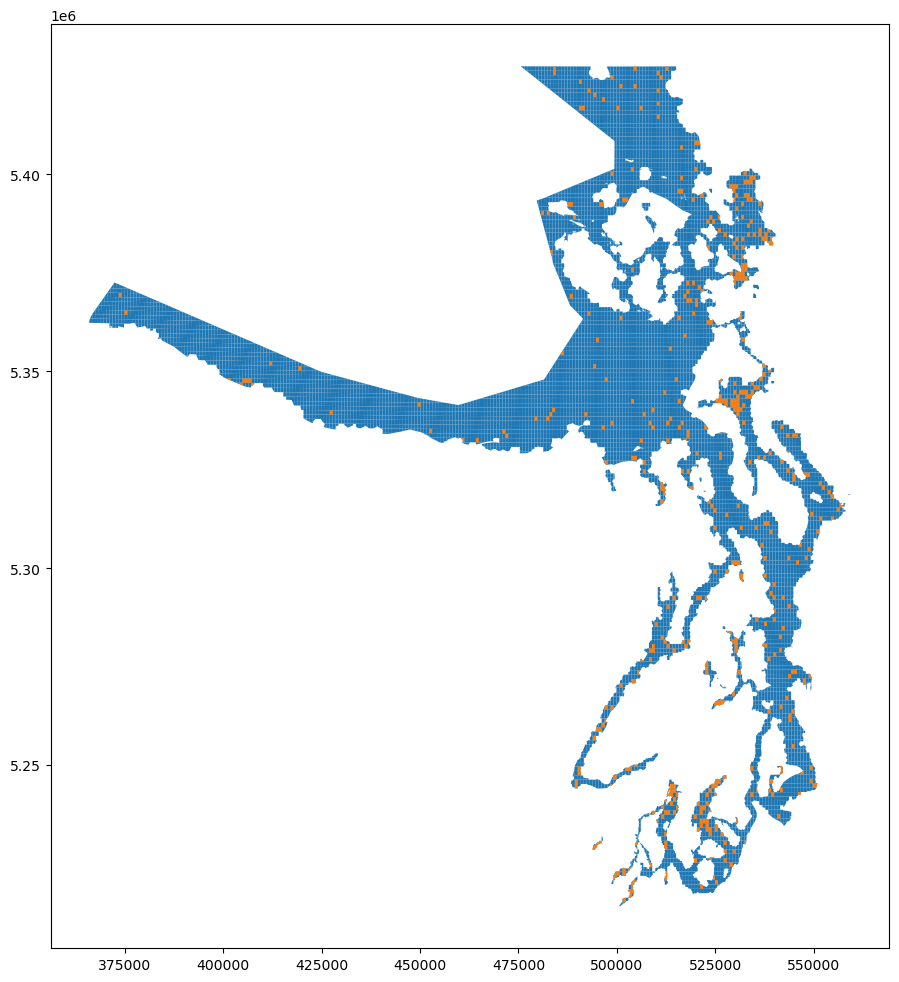

In [17]:
fig, ax = plt.subplots(figsize=(12,12))
gdf_303d.plot(ax=ax)
gdf_303d.loc[
    failed_matches.loc[pd.isna(failed_matches['ours'])].index
].plot(ax=ax, color='tab:red')
gdf_303d.loc[
    failed_matches.loc[~pd.isna(failed_matches['ours'])].index
].plot(ax=ax, color='tab:orange');

Indeed, using complete depth data eliminates the red area and at least one orange grid cell, but most of the rest is unaffected.

Now let's try the fix I already have prepared: a model output file that contains the "physical context" of the daily minimum DO including the surface elevation at the time of the measurement. This won't be perfect because the time of day of the daily minimum may not be the same between adjacent cells, and Ecology's method averages cell values from the same time together before calculating the daily minimum. But this is probably the best we can do, so let's see if it's enough.

In [18]:
with xr.open_dataset(run_file) as ds:
    MinDO_tce = ds[f'{model_var}_daily_min_wc']
    tide_tce = ds['zeta_daily_min']

In [19]:
tide_tce

<xarray.DataArray 'zeta_daily_min' (day: 360, node: 16012)> Size: 23MB
[5764320 values with dtype=float32]
Coordinates:
  * day      (day) datetime64[ns] 3kB 2014-01-06 2014-01-07 ... 2014-12-31
  * node     (node) int64 128kB 1 2 3 4 5 6 ... 16008 16009 16010 16011 16012

In [20]:
MinDO_303d = []
for day in MinDO_tce.coords['day']:
    print(day)
    gdf_tce_temp = gpd.GeoDataFrame({
        'depth': gdf_tce['depth'] + tide_tce.sel(day=day)
    }, geometry=gdf_tce['geometry'], crs=gdf_tce.crs, index=gdf_tce.index)
    regridder = calc_noncompliance.Regridder(gdf_tce_temp, gdf_303d, newgrid_mapping, 'tce', 'id_303d')
    MinDO_303d.append(regridder.regrid(MinDO_tce.sel(day=day).reset_coords('day', drop=True)))
newcoords = MinDO_303d[0].coords.copy()
newcoords['day'] = MinDO_tce.coords['day']
MinDO_303d = xr.DataArray(MinDO_303d, dims=['day'] + list(MinDO_303d[0].dims), coords=newcoords)

<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-06T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    day      datetime64[ns] 8B 2014-01-06
<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-07T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    day      datetime64[ns] 8B 2014-01-07
<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-08T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    day      datetime64[ns] 8B 2014-01-08
<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-09T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    day      datetime64[ns] 8B 2014-01-09
<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-10T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    day      datetime64[ns] 8B 2014-01-10
<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-11T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    day      datetime64[ns] 8B 2014-01-11
<xarray.DataArray 'day' ()> Size: 8B
array('2014-01-12T00:00:00.000000

TypeError: can only concatenate list (not "tuple") to list

In [21]:
MinDO_303d = xr.DataArray(MinDO_303d, dims=['day'] + list(MinDO_303d[0].dims), coords=newcoords)

In [22]:
MinDO_annual_303d = MinDO_303d.min(axis=(0,1))
domin_df = gpd.GeoDataFrame({
    'ecology': gdf_303d['min_exist'],
    'ours': MinDO_annual_303d
}, geometry=gdf_303d.geometry, crs=gdf_303d.crs, index=gdf_303d.index)
domin_df.head()

,ecology,ours,geometry
id_303d,,,
47122A9I7,6.7,6.703356,"POLYGON ((502171.347 5215145.776, 502162.733 5..."
47122A9I8,6.9,6.863575,"POLYGON ((501422.653 5215145.543, 501422.677 5..."
47122A9J6,6.5,6.498171,"POLYGON ((502940.13 5216257.39, 502940.302 521..."
47122A9J7,6.6,6.553808,"POLYGON ((502181.254 5216257.056, 502181.395 5..."
47122B5H9,5.3,5.263886,"POLYGON ((530971.919 5225228.193, 530972.418 5..."


In [23]:
failed_matches = domin_df.loc[domin_df['ours'].round(1) != domin_df['ecology']]
print(f'{len(failed_matches)} failed matches out of {len(domin_df)} grid cells')
failed_matches

474 failed matches out of 8224 grid cells


,ecology,ours,geometry
id_303d,,,
47122B6D6,5.3,5.247444,"POLYGON ((525687.109 5220757.557, 525687.437 5..."
47122B6E7,5.4,5.346902,"POLYGON ((524924.144 5221865.609, 524924.816 5..."
47122B6H1,5.3,5.242791,"POLYGON ((529456.454 5225220.435, 529456.58 52..."
47122B6I3,5.5,5.448352,"POLYGON ((527935.772 5226324.358, 527935.982 5..."
47122B6I8,5.6,5.549738,"POLYGON ((524147.843 5226307.64, 524148.498 52..."
...,...,...,...
48124C3H2,2.9,2.849324,"POLYGON ((401969.78 5348243.287, 401959.418 53..."
48124D0A8,2.9,2.849481,"POLYGON ((419822.868 5351299.684, 419808.67 53..."
48124D1B8,2.9,2.847050,"POLYGON ((412425.094 5352520.28, 412410.823 53..."


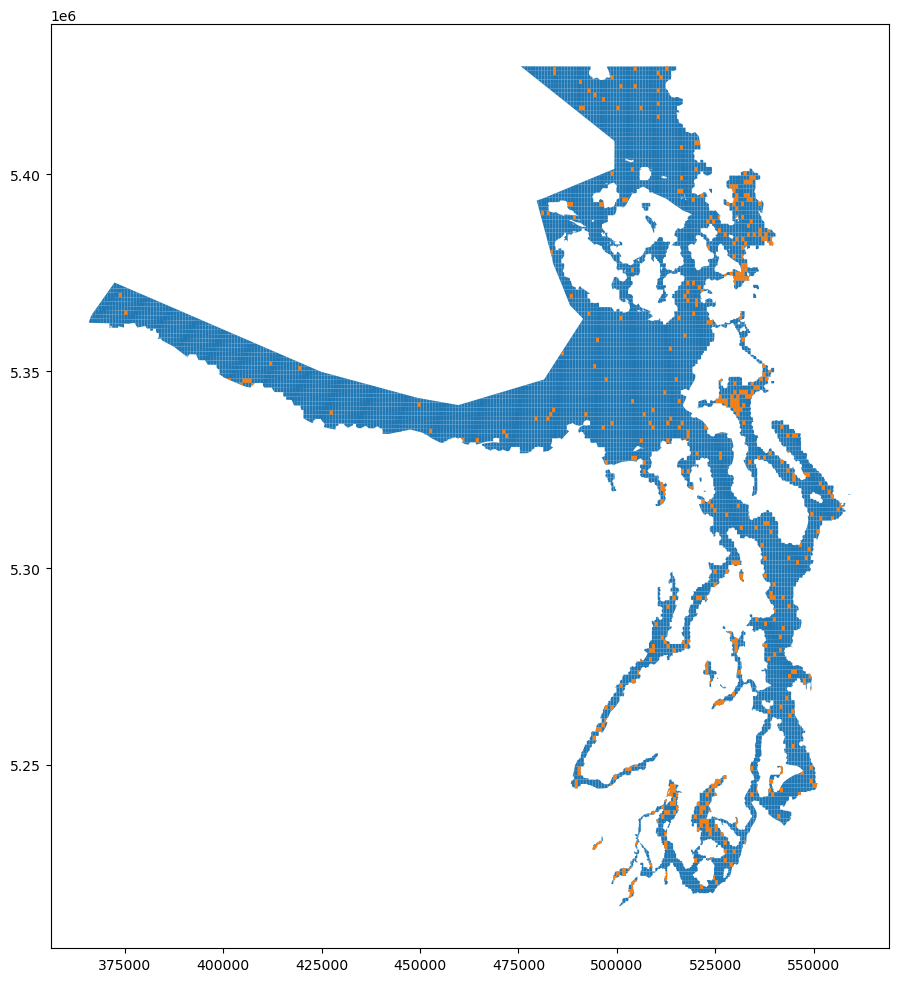

In [24]:
fig, ax = plt.subplots(figsize=(12,12))
gdf_303d.plot(ax=ax)
gdf_303d.loc[
    failed_matches.loc[~pd.isna(failed_matches['ours'])].index
].plot(ax=ax, color='tab:orange');

It's mainly the same areas as before.

In order to investigate this problem more efficiently, let's see if I can avoid regridding the entire year with every test. If I can examine one specific area, I can identify what few days of the year the DOmin falls in and just regrid those few days.

By opening my grid failure shapefile in QGIS I identified cell 48122C5C9 as one of the problematic ones in the center of the cluster in Whidbey Basin.

In [25]:
failed_matches.loc['48122C5C9']

ecology                                                   2.3
ours                                                  2.23134
geometry    POLYGON ((530353.3142999997 5341925.1526999995...
Name: 48122C5C9, dtype: object

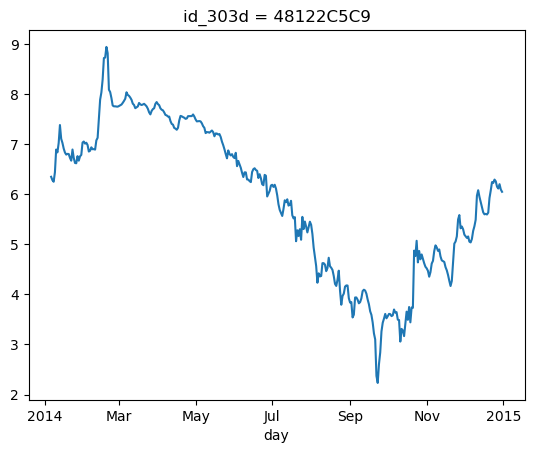

In [28]:
dailymin_ts = MinDO_303d.sel(id_303d='48122C5C9').min(dim='siglay')
dailymin_ts.plot();

In [30]:
dailymin_ts.idxmin()

<xarray.DataArray 'day' ()> Size: 8B
array('2014-09-23T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    id_303d  <U9 36B '48122C5C9'

In [31]:
dailymin_ts.argmin()

/home/benr/miniforge3/envs/psi_ssm/lib/python3.14/site-packages/xarray/core/dataarray.py:6318: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


<xarray.DataArray ()> Size: 8B
array(260)
Coordinates:
    id_303d  <U9 36B '48122C5C9'